# Make plots for physics performance

In [26]:
!pip install hist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [hist]3/4 [hist]print]gram]


In [1]:
# import packages
import uproot
import awkward as ak
from scipy.interpolate import make_smoothing_spline, make_interp_spline
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
from sakura import *
import seaborn as sns
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

DRAFT =  False #True
setStyle(customized=False)
THELABEL =  "Private Work" #"Simulation Work in progress"

### Load data

In [2]:
sns.color_palette(["#E15050","#112B5A", "#CCCCCC", "#346ED9", "#9874DB", "#FFBE0B", "#95D000", "#FAA6FF", "#7F7F7F"])

[(0.8823529411764706, 0.3137254901960784, 0.3137254901960784),
 (0.06666666666666667, 0.16862745098039217, 0.35294117647058826),
 (0.8, 0.8, 0.8),
 (0.20392156862745098, 0.43137254901960786, 0.8509803921568627),
 (0.596078431372549, 0.4549019607843137, 0.8588235294117647),
 (1.0, 0.7450980392156863, 0.043137254901960784),
 (0.5843137254901961, 0.8156862745098039, 0.0),
 (0.9803921568627451, 0.6509803921568628, 1.0),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]

In [4]:
theCOLORS = {
    "MVA_NP" : "#E15050", #"#95D000",
    "NP + DNN" :"#346ED9", #"#95D000",
}
CUTS = list(theCOLORS.keys())
DIR_ = "plots/results"

# import layer pairs
from simplotter.dataconfig.layerPairs import simplePixelLayerPairs, NonSkippingLayerPairs

filesPT = {
    cut : uproot.open("BsMuMu-thesis/%s_DQM.root" % (cut))["DQMData/Run 1/HLT/Run summary/Tracking/ValidationWRTtp"] for cut in CUTS
}

filesHits = {
    cut : uproot.open("BsMuMu-thesis/%s_DQM.root" % (cut))["DQMData/Run 1/HLT/Run summary/"] for cut in CUTS
}

In [52]:
COLLECTIONS = {#"GeneralTracks" : "hltGeneral_hltAssociatorByHits", 
               "PixelTracks" : "hltPhase2Pixel_hltAssociatorByHits",
               "PixelTracks_noHP": "hltPhase2PixelCAExtension_hltAssociatorByHits",
               #"InitialStepTracks" : "hltInitialStepTrackSelectionHighPurity_hltAssociatorByHits", 
               #"HighPtTripletStepTracks" : "hltHighPtTripletStepTrackSelectionHighPurity_hltAssociatorByHits", 
               #"T5s" : "hltInitialStepT5TCLST_hltAssociatorByHits",
               #"pTs" : "hltInitialStepTrackSelectionHighPuritypTTCLST_hltAssociatorByHits",
               #"pLSs" : "hltInitialStepTrackSelectionHighPuritypLSTCLST_hltAssociatorByHits",
              }
COLLS = COLLECTIONS.keys()

DATA = {}
for cut in CUTS:
    DATA[cut] = {}
    for coll in COLLS:
        try:
            colldir = COLLECTIONS[coll]
            if (((coll != "HighPtTripletStepTracks") and (coll != "T5s") and (coll != "pTs") and (coll != "pLSs")) or 
                ((coll == "HighPtTripletStepTracks") and (cut in CUTS[:3])) or 
                ((coll == "T5s") and (("T5" in cut) or ("LST" in cut))) or
                ((coll == "pTs") and ("LST" in cut)) or
                ((coll == "pLSs") and ("LST" in cut))
               ):
                DATA[cut][coll] = {
                    "efficiencyVsEta": Hist(filesPT[cut][colldir], "efficiency", "eta"),
                    "fakeVsEta": Hist(filesPT[cut][colldir], "fake", "eta"),
                    "dupVsEta": Hist(filesPT[cut][colldir], "duplicate", "eta"),
                    "efficiencyVsPt": Hist(filesPT[cut][colldir], "efficiency", "pt"),
                    "fakeVsPt": Hist(filesPT[cut][colldir], "fake", "pt"),
                    "dupVsPt": Hist(filesPT[cut][colldir], "duplicate", "pt"),
                    "efficiencyVsPhi": Hist(filesPT[cut][colldir], "efficiency", "phi"),
                    "fakeVsPhi": Hist(filesPT[cut][colldir], "fake", "phi"),
                    "dupVsPhi": Hist(filesPT[cut][colldir], "duplicate", "phi"),
                    "efficiencyVsVertex": Hist(filesPT[cut][colldir], "effic_vs_vertpos"),
                    "fakeVsVertex": Hist(filesPT[cut][colldir], "fakerate_vs_vertpos"),
                    "efficiencyVsdxy": Hist(filesPT[cut][colldir], "effic_vs_dxy"),
                    "fakeVsdxy": Hist(filesPT[cut][colldir], "fakerate_vs_dxy"),
                    "hitsVsEta": Hist(filesPT[cut][colldir], "hits_eta"),
                    "pixelHitsVsEta": Hist(filesPT[cut][colldir], "PXLhits_vs_eta"),
                    "stripHitsVsEta": Hist(filesPT[cut][colldir], "STRIPhits_vs_eta"),
                    "ptresVsEta": Hist(filesPT[cut][colldir], "ptres_vs_eta_Sigma"),
                    "phiresVsEta": Hist(filesPT[cut][colldir], "phires_vs_eta_Sigma"),
                    "dxyresVsEta": Hist(filesPT[cut][colldir], "dxyres_vs_eta_Sigma"),
                    "dzresVsEta": Hist(filesPT[cut][colldir], "dzres_vs_eta_Sigma"),
                }
        except:
            print(coll, 'not available in', colldir)
            


for cut in CUTS:
    for coll in COLLS:
        try:
            if (((coll != "HighPtTripletStepTracks") and (coll != "T5s") and (coll != "pTs") and (coll != "pLSs")) or 
                ((coll == "HighPtTripletStepTracks") and (cut in CUTS[:3])) or 
                ((coll == "T5s") and (("T5" in cut) or ("LST" in cut))) or
                ((coll == "pTs") and ("LST" in cut)) or
                ((coll == "pLSs") and ("LST" in cut))
               ):
                colldir = COLLECTIONS[coll]
                DATA[cut][coll]["fake+dupVsEta"] = getSumHist(DATA[cut][coll]["fakeVsEta"], DATA[cut][coll]["dupVsEta"])
                DATA[cut][coll]["fake+dupVsPt"] = getSumHist(DATA[cut][coll]["fakeVsPt"], DATA[cut][coll]["dupVsPt"])
                DATA[cut][coll]["fake+dupVsPhi"] = getSumHist(DATA[cut][coll]["fakeVsPhi"], DATA[cut][coll]["dupVsPhi"])
    
            DATA[cut][coll]["IT-B1-Cluster-DY"] = Hist(filesHits[cut]["TrackerPhase2ITClusterV/Barrel/Layer1"], "Delta_Y_Pixel")
            DATA[cut][coll]["IT-B1-RecHit-DY"] = Hist(filesHits[cut]["TrackerPhase2ITRecHitV/Barrel/Layer1"], "Delta_Y")
            DATA[cut][coll]["IT-B1-RecHit-DX"] = Hist(filesHits[cut]["TrackerPhase2ITRecHitV/Barrel/Layer1"], "Delta_X")
            DATA[cut][coll]["OT-B1-Cluster-DX"] = Hist(filesHits[cut]["TrackerPhase2OTClusterV/Barrel/Layer1"], "Delta_X_Pixel")
        except:
            continue

PixelTracks_noHP not available in hltPhase2PixelCAExtension_hltAssociatorByHits
PixelTracks_noHP not available in hltPhase2PixelCAExtension_hltAssociatorByHits


In [53]:
from scipy.stats import binomtest
def getEfficiency(passing, total):
    yEff = []
    yEffErrUp = []
    yEffErrLow = []
    for yPass, yTot in zip(passing, total):
        if yTot>0:
            # error calculation with eff
            result = binomtest(k=int(yPass), n=int(yTot))
            yEff.append(result.statistic)
            yEffErrLow.append(result.proportion_ci(0.683).low)
            yEffErrUp.append(result.proportion_ci(0.683).high)
        else:
            yEff.append(0)
            yEffErrLow.append(0)
            yEffErrUp.append(0)
    return np.array(yEff), np.array(yEffErrLow), np.array(yEffErrUp)


def NtupletLine(num, hist="numLayers", X="eta", cut="CAExtNewCuts"):
    # load data
    NhitsVsX = Hist2D(filesSD[cut]["reference"], "%s_vs_%s" % (hist, X))
    
    all = np.sum(NhitsVsX.values, axis=1)
    moreThanNhits = np.sum(NhitsVsX.values[:, num+1:], axis=1)

    # calculate max efficiency   
    y, yLow, yUp = getEfficiency(moreThanNhits, all)

    x = NhitsVsX.edges_x

    return (x, y, yLow, yUp)

#LinesLayers = {k: NtupletLine(k, hist="numLayers") for k in [3,4,5,6]}
#LineLimit = Hist(filesSD["CAExtNewCuts"]["reference"], "effConfigLimit_vs_eta")
#LinesLayersPt = {k: NtupletLine(k, hist="numLayers", X="pt") for k in [3,4,5,6]}
#LineLimitPt = Hist(filesSD["CAExtNewCuts"]["reference"], "effConfigLimit_vs_pt")

def getDiffHist(Hist1, Hist2=None):
    """
    Calculates the sum Histogram for two given histograms. The error is calculated via error propagation.
    Note, this does not yield the correct error if an efficiency is wanted!
    """
    sumHist = Hist()
    sumHist.edges = Hist1.edges

    if Hist2 is None:
        sumHist.values = 0*Hist1.values
        sumHist.errors = Hist1.errors
    else:
        sumHist.values = Hist1.values - Hist2.values
        sumHist.errors = np.sqrt((Hist1.errors)**2 + (Hist2.errors)**2)

    return sumHist

def plotEfficiency( HIST = "efficiencyVsEta",
                    CURVS = {
                        "Legacy" : ["Legacy", "PixelTracks"],
                        "Patatrack" : ["Patatrack", "PixelTracks"],
                        "CAExt" : ["CAExt", "PixelTracks"],
                    },
                    MARKERS = ["s", "v", "o", "x", "^"],
                    COLORS =["#E15050", "#112B5A", "#346ED9", "#9874DB", "#95D000"],
                    reference = None,
                    refColor = "#DDDDDD",
                    limit=None,
                    Ylim=(0,1),
                    ratioYlim=(None, None),
                    ratioTYPE="ratio",
                    Xlim=(None,None),
                    XLABEL=None,
                    YLABEL=None,
                    YSCALE=None,
                    XSCALE=None,
                    LEGEND=True,
                    REMOVETICKS=False,
                    RATIO=False,
                    FACTOR=None,
                    #REMOVELOWSTATISTICS=False,
                    saveas=None
                  ):

    if reference is None:
        reference=False
    else:
        genLabel, trackLabel, refLabel = reference
        reference=True

    ISEFF = ("eff" in HIST)
    if RATIO:
        ADDPLACE = 0.8 if ISEFF else 0.6
    else:
        ADDPLACE = 0.65 if ISEFF else 0.54

    if RATIO:
        fig, (ax1, ax2) = plt.subplots(2, sharex=True, height_ratios=[5, 1], figsize=(10, 11))
    else:
        fig, ax1 = plt.subplots(1, figsize=(10, 10))
    
    plotname = HIST + "_"

    
    
    for i, label in enumerate(CURVS.keys()):
        curv = CURVS[label]
        plotname += ("_" + curv[1] + curv[0]) if i==0 else ("_vs_" + curv[0])
        theHist = DATA[curv[0]][curv[1]][HIST]
        theHist.plot(ax=ax1, marker=MARKERS[i], color=COLORS[i], label=label)
        if RATIO:
            if i==0:
                refHist = DATA[curv[0]][curv[1]][HIST]
                if ratioTYPE=="ratio":
                    base = getRatioHist(refHist)
                    ax2.axhline(1, linestyle="dashed", color=COLORS[0])
                    base = ax2.stairs(1+base.errors/2, base.edges, baseline=1-base.errors/2, fill=True, alpha=0.25, color=COLORS[0])
                else:
                    base = getDiffHist(refHist)
                    ax2.axhline(0, linestyle="dashed", color=COLORS[0])
                    base = ax2.stairs(base.errors/2, base.edges, baseline=base.errors/2, fill=True, alpha=0.25, color=COLORS[0])
            else:
                if ratioTYPE=="ratio":
                    ratio = getRatioHist(theHist, refHist)
                    ratio.plot(marker=MARKERS[i], color=COLORS[i], ax=ax2)
                else:
                    ratio = getDiffHist(theHist, refHist)
                    ratio.plot(marker=MARKERS[i], color=COLORS[i], ax=ax2)
    
    handles, labels = ax1.get_legend_handles_labels()
    if RATIO:
        handles[int(reference)] = (handles[int(reference)], base)
    order = list(range(reference, len(CURVS.keys()) + reference))
    if reference:
        cut = genLabel
        plotname += "_vs_" + cut
        HistI = DATA[genLabel][trackLabel][HIST]
        ax1.stairs(HistI.values, HistI.edges, label=refLabel, color=refColor, fill=True)
    handles = [handles[idx] for idx in order]
    labels = [labels[idx] for idx in order]    

    if limit is not None:
        x, y, yLow, yUp = limit
        quadrHandle = ax1.stairs(y, x, linestyle="dashed", color="k")
        quadrFillHandle = ax1.stairs(yUp, x, baseline =yLow, color="k", alpha=0.2, fill=True)
        handles.append((quadrHandle, quadrFillHandle))
        labels.append("Geometry limit")

    if LEGEND:
        ax1.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.025, (0.78 if ISEFF else 0.84) if RATIO else (0.8 if ISEFF else 0.86)),
                   handletextpad=0.25)

    xlabel(None, ax=ax1)
    ax = ax2 if RATIO else ax1
    if XLABEL is None:
        if "Eta" in HIST:
            xlabel("eta", ax=ax)
        elif "Pt" in HIST:
            xlabel("pt", ax=ax)
    else:
        xlabel(XLABEL, ax=ax)

    if YLABEL is not None:
        ylabel(YLABEL, ax=ax1)
    
    if RATIO:
        ylabel("Ratio " if ratioTYPE=="ratio" else "Difference", loc="top", ax=ax2)
    if ("Pt" in HIST) or (XSCALE=="log"):
        plt.xscale("log")
    if YSCALE is not None:
        ax1.set_yscale(YSCALE)
        factor = 10 ** (np.log10(Ylim[1] / Ylim[0]) * ADDPLACE)
        YlimTrue = [Ylim[0], Ylim[1] * factor]
    else:
        YlimTrue = [Ylim[0], Ylim[1] + ADDPLACE*(Ylim[1]-Ylim[0])]
    ax1.set_ylim(YlimTrue)
    ax1.set_xlim(Xlim)
    
    if REMOVETICKS:
        ytickslocs = ax1.get_yticks()
        ax1.set_yticks([y_ for y_ in ytickslocs if (y_ <= Ylim[1]) and (y_ >= Ylim[0])])
        ytickslocs = ax1.get_yticks()
        yticklabels = ax1.get_yticklabels()
        ax1.set_yticklabels([(yl_ if y_!=1 else ("1" if YSCALE=="log" else "1.0")) for y_, yl_ in zip(ytickslocs, yticklabels)])
        ytickslocs = ax1.get_yticks(minor=True)
        ax1.set_yticks([y_ for y_ in ytickslocs if (y_ <= Ylim[1]) and (y_ >= Ylim[0])], minor=True)
    
    ax1.grid(1)

    if RATIO:
        ax2.set_ylim(ratioYlim)
        ax2.grid(1)
        # add little arrows for points out of range of ratio plot
        ylim = ax2.get_ylim()
        dy = ylim[1] - ylim[0]
        yup = ylim[1] - dy/50
        ylo = ylim[0] + dy/50
        for i, label in enumerate(CURVS.keys()):
            curv = CURVS[label]
            theHist = DATA[curv[0]][curv[1]][HIST]
            if i==0:
                xpos = (theHist.edges[1:] + theHist.edges[:-1]) / 2
            else:
                ratio = getRatioHist(theHist, refHist)
                # lower points
                mask = ratio.values < ylim[0]
                ax2.scatter(xpos[mask], ylo*np.ones(np.sum(mask)), marker="v", color=COLORS[i], facecolors="none", sizes=30*np.ones(np.sum(mask)))
                # higher points
                mask = ratio.values > ylim[1]
                ax2.scatter(xpos[mask], yup*np.ones(np.sum(mask)), marker="^", color=COLORS[i], facecolors="none", sizes=30*np.ones(np.sum(mask)))

    if FACTOR is not None:
        if YSCALE is not None and YSCALE=="log":
            ticks = mpl.ticker.FuncFormatter(lambda x, pos: r"$10^{" + "%i" % np.log10(x*FACTOR) + r"}$")
        else:
            ticks = mpl.ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*FACTOR))
        ax1.yaxis.set_major_formatter(ticks)

    if DRAFT:
        ax1.text(0.5, 0.5, 'DRAFT', transform=ax.transAxes,
                fontsize=150, color='gray', alpha=0.25,
                ha='center', va='center', rotation=30)
    # add the CMS label
    datalabel = r"$B_s^0 \to \mu^+\mu^-$, 200 PU, HLT pixel tracks" + ("" if not ISEFF else "\n" +  
                (r"$|z_\text{vertex}| < 30\,\text{cm}, r_\text{vertex} < 2.5\,\text{cm}$" if ISEFF and "Pt" in HIST else
                (r"$p_\text{T}>0.9\,\text{GeV}, |z_\text{vertex}| < 30\,\text{cm}$" if ISEFF and "Vertex" in HIST else 
                (r"$p_\text{T}>0.9\,\text{GeV}, |z_\text{vertex}| < 30\,\text{cm}, r_\text{vertex} < 2.5\,\text{cm}$"))))
    exptext, expsuffix, supptext, explumi = cmslabel(llabel=THELABEL, rlabel=datalabel, ax=ax1, loc=4)
    explumi.set_fontsize(explumi.get_fontsize() / 1.25)
    #explumi.set_text(datalabel)
    plt.subplots_adjust(hspace=0.)
    if saveas is not None:
        savefig(DIR + "/%s.%s" % (plotname, saveas))
    # Export histogram binning
    out = np.vstack([theHist.edges[:-1],   # low edges
                     theHist.edges[1:],    # high edges
                     theHist.values        # contents
                    ]).T
    
    filename = f"binning_{HIST}_{label}.txt"
    np.savetxt(filename, out,
               header="lowEdge highEdge value",
               fmt="%.12g")
    print(f"Saved binning to {filename}")

    plt.show()


def plotLegend(CURVS, COLORS, MARKERS,
                    limit=None,
                    reference = None,
                    refColor = "#DDDDDD"):
    HIST = "efficiencyVsEta"

    if reference is None:
        reference=False
    else:
        genLabel, trackLabel, refLabel = reference
        reference=True
    
    fig, (ax1, ax2) = plt.subplots(2, sharex=True, height_ratios=[3, 1], figsize=(10, 11))
    
    for i, label in enumerate(CURVS.keys()):
        curv = CURVS[label]
        theHist = DATA[curv[0]][curv[1]][HIST]
        theHist.plot(ax=ax1, marker=MARKERS[i], color=COLORS[i], label=label)
        if i==0:
            refHist = DATA[curv[0]][curv[1]][HIST]
            base = getRatioHist(refHist)
            ax2.axhline(1, linestyle="dashed", color=COLORS[0])
            base = ax2.stairs(1+base.errors/2, base.edges, baseline=1-base.errors/2, fill=True, alpha=0.25, color=COLORS[0])
    
    handles, labels = ax1.get_legend_handles_labels()
    handles[int(reference)] = (handles[int(reference)], base)
    order = list(range(reference, len(CURVS.keys()) + reference))
    if reference:
        cut = genLabel
        HistI = DATA[genLabel][trackLabel][HIST]
        ax1.stairs(HistI.values, HistI.edges, label=refLabel, color=refColor, fill=True)
    
    handles, labels = ax1.get_legend_handles_labels()
    handles[int(reference)] = (handles[int(reference)], base)
    order = list(range(reference, len(CURVS.keys()) + reference))
    if reference:
        order.append(0)
    handles = [handles[idx] for idx in order]
    labels = [labels[idx] for idx in order]    

    if limit is not None:
        x, y, yLow, yUp = limit
        quadrHandle = ax1.stairs(y, x, linestyle="dashed", color="k")
        quadrFillHandle = ax1.stairs(yUp, x, baseline =yLow, color="k", alpha=0.2, fill=True)
        handles.append((quadrHandle, quadrFillHandle))
        labels.append("Geometry limit")
    plt.close(1)

    fig = plt.figure(figsize=(1,1))
    plt.legend(handles, labels)
    plt.axis('off')
    savefig(DIR + "/legend.pdf")
    plt.show()

In [54]:
def fillEfficiency(
        HIST="efficiencyVsEta",
        CURVS={
            "Legacy": ["Legacy", "PixelTracks"],
            "Patatrack": ["Patatrack", "PixelTracks"],
            "CAExt": ["CAExt", "PixelTracks"],
        },
        MARKERS=["s", "v", "o", "x", "^"],
        COLORS=["#E15050", "#112B5A", "#346ED9", "#9874DB", "#95D000"],
        reference=None,
        refColor="#DDDDDD",
        limit=None,
        Ylim=(0, 1),
        ratioYlim=(None, None),
        ratioTYPE="ratio",
        Xlim=(None, None),
        XLABEL=None,
        YLABEL=None,
        YSCALE=None,
        XSCALE=None,
        LEGEND=True,
        REMOVETICKS=False,
        RATIO=False,
        FACTOR=None,
        INSET = False,
        FILLCURVES=True,
        FILLALPHA=0.20,
        saveas=None
):

    if reference is None:
        reference = False
    else:
        genLabel, trackLabel, refLabel = reference
        reference = True

    ISEFF = True#("eff" in HIST)

    if RATIO or True:
        ADDPLACE = 0.8 if ISEFF else 0.6
    else:
        ADDPLACE = 0.65 if ISEFF else 0.54

    if RATIO:
        fig, (ax1, ax2) = plt.subplots(
            2,
            sharex=True,
            height_ratios=[5, 1],
            figsize=(9, 12)
        )
    else:
        fig, ax1 = plt.subplots(1, figsize=(9, 11))

    plotname = HIST + "_"

    # ==========================================================
    # NEW: keep previous histogram for filled overlays
    # ==========================================================
    prevHist = None

    for i, label in enumerate(CURVS.keys()):

        curv = CURVS[label]

        plotname += (
            ("_" + curv[1] + curv[0]) if i == 0
            else ("_vs_" + curv[0])
        )

        theHist = DATA[curv[0]][curv[1]][HIST]

        # ------------------------------------------------------
        # Fill area between curves
        # ------------------------------------------------------
        if FILLCURVES and (prevHist is not None):

            ax1.stairs(
                theHist.values,
                theHist.edges,
                baseline=prevHist.values,
                fill=True,
                alpha=FILLALPHA,
                color=COLORS[i],
                linewidth=0
            )

        # ------------------------------------------------------
        # Draw visible curve
        # ------------------------------------------------------
        marker_type = None if FILLCURVES else MARKERS[i] 
        theHist.plot(
            ax=ax1,
            marker=marker_type,
            color=COLORS[i],
            label=label
        )

        # Store current histogram
        prevHist = theHist

        # ======================================================
        # Ratio panel
        # ======================================================
        if RATIO:

            if i == 0:

                refHist = DATA[curv[0]][curv[1]][HIST]

                if ratioTYPE == "ratio":

                    base = getRatioHist(refHist)

                    ax2.axhline(
                        1,
                        linestyle="dashed",
                        color=COLORS[0]
                    )

                    base = ax2.stairs(
                        1 + base.errors / 2,
                        base.edges,
                        baseline=1 - base.errors / 2,
                        fill=True,
                        alpha=0.25,
                        color=COLORS[0]
                    )

                else:

                    base = getDiffHist(refHist)

                    ax2.axhline(
                        0,
                        linestyle="dashed",
                        color=COLORS[0]
                    )

                    base = ax2.stairs(
                        base.errors / 2,
                        base.edges,
                        baseline=base.errors / 2,
                        fill=True,
                        alpha=0.25,
                        color=COLORS[0]
                    )

            else:

                if ratioTYPE == "ratio":

                    ratio = getRatioHist(theHist, refHist)

                    ratio.plot(
                        marker=MARKERS[i],
                        color=COLORS[i],
                        ax=ax2
                    )

                else:

                    ratio = getDiffHist(theHist, refHist)

                    ratio.plot(
                        marker=MARKERS[i],
                        color=COLORS[i],
                        ax=ax2
                    )

    # ==========================================================
    # Legend handling
    # ==========================================================
    handles, labels = ax1.get_legend_handles_labels()

    if RATIO:
        handles[int(reference)] = (handles[int(reference)], base)

    order = list(range(reference, len(CURVS.keys()) + reference))

    if reference:

        cut = genLabel
        plotname += "_vs_" + cut

        HistI = DATA[genLabel][trackLabel][HIST]

        ax1.stairs(
            HistI.values,
            HistI.edges,
            label=refLabel,
            color=refColor,
            fill=True
        )

    handles = [handles[idx] for idx in order]
    labels = [labels[idx] for idx in order]

    # ==========================================================
    # Geometry limit
    # ==========================================================
    if limit is not None:

        x, y, yLow, yUp = limit

        quadrHandle = ax1.stairs(
            y,
            x,
            linestyle="dashed",
            color="k"
        )

        quadrFillHandle = ax1.stairs(
            yUp,
            x,
            baseline=yLow,
            color="k",
            alpha=0.2,
            fill=True
        )

        handles.append((quadrHandle, quadrFillHandle))
        labels.append("Geometry limit")

    # ==========================================================
    # Legend
    # ==========================================================
    if LEGEND:

        ax1.legend(
            handles,
            labels,
            loc='upper left',
            bbox_to_anchor=(
                0.025,
                (0.78 if ISEFF else 0.78)
                if RATIO or True
                else (0.72 if ISEFF else 0.86)
            ),
            ncol=1,         
            columnspacing=1.0,
            handletextpad=0.25
        )

    # ==========================================================
    # Labels
    # ==========================================================
    xlabel(None, ax=ax1)

    ax = ax2 if RATIO else ax1

    if XLABEL is None:

        if "Eta" in HIST:
            xlabel("eta", ax=ax)

        elif "Pt" in HIST:
            xlabel("pt", ax=ax)

    else:
        xlabel(XLABEL, ax=ax)

    if YLABEL is not None:
        ylabel(YLABEL, ax=ax1)

    if RATIO:
        ylabel(
            "Ratio " if ratioTYPE == "ratio" else "Difference",
            loc="top",
            ax=ax2
        )

    # ==========================================================
    # Scales
    # ==========================================================
    if ("Pt" in HIST) or (XSCALE == "log"):
        plt.xscale("log")

    if YSCALE is not None:

        ax1.set_yscale(YSCALE)

        factor = 10 ** (
            np.log10(Ylim[1] / Ylim[0]) * ADDPLACE
        )

        YlimTrue = [Ylim[0], Ylim[1] * factor]

    else:

        YlimTrue = [
            Ylim[0],
            Ylim[1] + ADDPLACE * (Ylim[1] - Ylim[0])
        ]

    ax1.set_ylim(YlimTrue)
    ax1.set_xlim(Xlim)

    ax1.grid(1)

    # ==========================================================
    # Ratio formatting
    # ==========================================================
    if RATIO:

        ax2.set_ylim(ratioYlim)
        ax2.grid(1)
    # ==========================================================
    # CMS label
    # ==========================================================
    
    if DRAFT:
        ax1.text(
            0.5,
            0.5,
            'DRAFT',
            transform=ax.transAxes,
            fontsize=150,
            color='gray',
            alpha=0.25,
            ha='center',
            va='center',
            rotation=30
        )
    
    datalabel = (
        r"$B_s^0 \to \mu^+\mu^-$ + 200 PU, "
        r"HLT pixel tracks"
        + (
            "" if not ISEFF else "\n" +
            (
                r"$|z_\text{vertex}| < 30\,\text{cm}, "
                r"r_\text{vertex} < 2.5\,\text{cm}$"
                if ISEFF and "Pt" in HIST else
                (
                    r"$p_\text{T}>0.9\,\text{GeV}, "
                    r"|z_\text{vertex}| < 30\,\text{cm}$"
                    if ISEFF and "Vertex" in HIST else
                    (
                        r"$p_\text{T}>0.9\,\text{GeV}, "
                        r"|z_\text{vertex}| < 30\,\text{cm}, "
                        r"r_\text{vertex} < 2.5\,\text{cm}$"
                    )
                )
            )
        )
    )

    cmslabel(
        llabel=THELABEL,
        rlabel=datalabel,
        ax=ax1,
        loc=4
    )
    
    #explumi.set_fontsize(
    #    explumi.get_fontsize() / 1.25
    #)

    # ==========================================================
    # INSET ZOOM (efficiency plateau)
    # ==========================================================
    if INSET:
        axins = inset_axes(
            ax1,
            width="60%",
            height="45%",
            loc="lower center",
            borderpad=2
        )
        
        # copy same curves into inset
        prevHist = None
        for i, label in enumerate(CURVS.keys()):
            curv = CURVS[label]
            theHist = DATA[curv[0]][curv[1]][HIST]

            if FILLCURVES and (prevHist is not None):

                axins.stairs(
                    theHist.values,
                    theHist.edges,
                    baseline=prevHist.values,
                    fill=True,
                    alpha=FILLALPHA,
                    color=COLORS[i],
                    linewidth=0
                )
        
            theHist.plot(
                ax=axins,
                marker=None,              # usually cleaner in inset
                color=COLORS[i],
                label=None
            )
            prevHist = theHist
        
        # zoom region
        axins.set_ylim(0.75, 0.95)
        
        # same x-range as main plot
        axins.set_xlim(ax1.get_xlim())
        
        # clean look
        axins.grid(1)
        axins.tick_params(labelsize=15)
        
        # optional: remove clutter
        axins.set_xlabel("")
        axins.set_ylabel("")
    
        mark_inset(
            ax1,
            axins,
            loc1=2, loc2=4,  # corners of rectangle
            fc="none",
            ec="gray",
            alpha=0.9
        )

    # ==========================================================
    # Save
    # ==========================================================
    plt.subplots_adjust(hspace=0.)
    #fig.tight_layout(rect=[0, 0, 1, 0.96])

    if saveas is not None:
        savefig(DIR + "/%s.%s" % (plotname, saveas))

    plt.show()

### Pixel hits

In [36]:
DIR = DIR_ #+ "/PixelTracking"
saveas = "png"
LEGEND = True

CURVS = {
    "Baseline" : ["Baseline", "PixelTracks"],
    "Baseline allowing skipping quad": ["Baseline allowing skipping quad", "PixelTracks"],
    "Torch DNN allowing skipping quad" : ["Torch DNN allowing skipping quad", "PixelTracks"],
    #"New Patatrack": ["New Patatrack", "PixelTracks"],
    #"New Patatrack + DNN": ["New Patatrack + DNN", "PixelTracks"],
    #"Patatrack (baseline, IT layers only)" : ["PatatrackBase", "PixelTracks"],
    #"Patatrack (IT layers only)" : ["PatatrackIT", "PixelTracks"],
    #"Alpaka" : ["AlpakaLST", "PixelTracks"],
    #"AlpakaCAExt" : ["AlpakaSingleIterCAExt", "PixelTracks"],
    #"Patatrack (IT + 3 OT layers)" : ["PatatrackOptExt", "PixelTracks"],
    #"Patatrack (IT + 3 OT layers) Eta1Fix" : ["PatatrackOptExt_Eta1Fix", "PixelTracks"],
}
COLORS = [theCOLORS[CURVS[c][0]] for c in CURVS.keys()]
#COLORS = ["#CCCCCC", "#E15050", "#346ED9", "#112B5A"]
MARKERS = ["s", "v", "o", "^", "D"]
RATIO = False

KeyError: 'Baseline'

AttributeError: 'NoneType' object has no attribute 'set_fontsize'

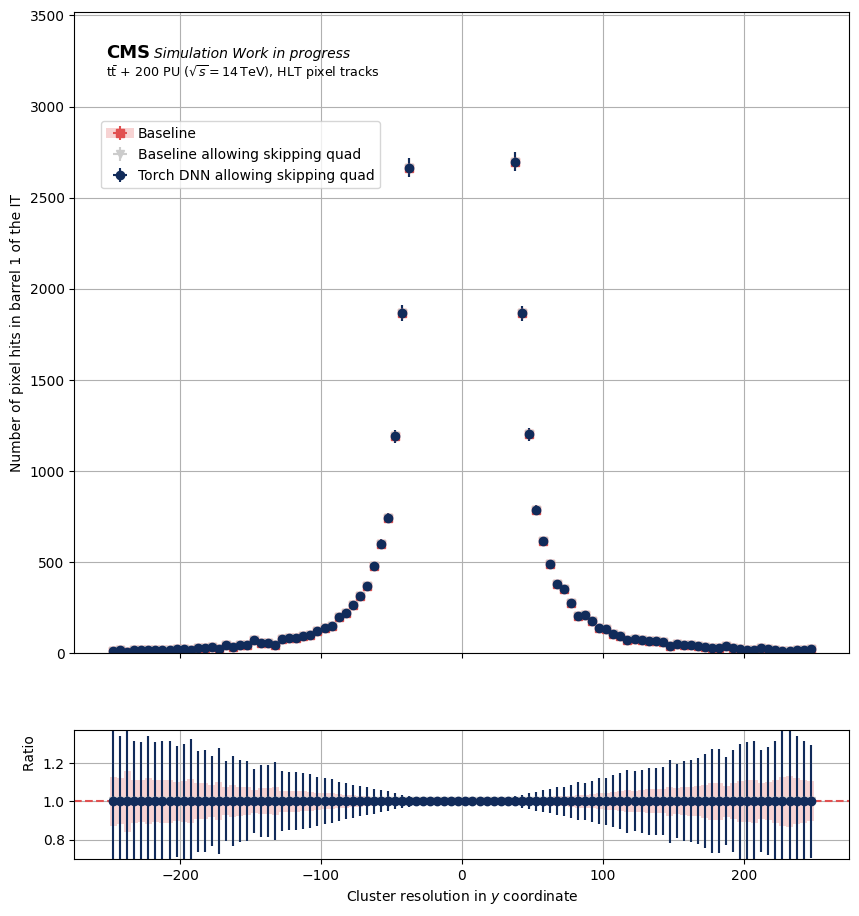

In [8]:
explumi = plotEfficiency( HIST = "IT-B1-Cluster-DY",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Number of pixel hits in barrel 1 of the IT",
                XLABEL="Cluster resolution in $y$ coordinate",
                Ylim=(0,2200),
                ratioYlim=(0.7, 1.37),
                #Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                #REMOVETICKS=True,
                RATIO="ratio",
                saveas=saveas
              )

In [ ]:
explumi = plotEfficiency( HIST = "IT-B1-RecHit-DY",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Number of pixel hits in barrel 1 of the IT",
                XLABEL="RecHit resolution in $y$ coordinate",
                Ylim=(0,1000),
                ratioYlim=(0.7, 1.37),
                #Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                #REMOVETICKS=True,
                RATIO="ratio",
                saveas=saveas
              )

In [ ]:
explumi = plotEfficiency( HIST = "IT-B1-RecHit-DX",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Number of pixel hits in barrel 1 of the IT",
                XLABEL="RecHit resolution in $x$ coordinate",
                Ylim=(0,3800),
                ratioYlim=(0.7, 1.37),
                #Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                #REMOVETICKS=True,
                RATIO="ratio",
                saveas=saveas
              )

In [ ]:
explumi = plotEfficiency( HIST = "OT-B1-Cluster-DX",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Number of pixel hits in barrel 1 of the OT",
                XLABEL="Cluster resolution in $x$ coordinate",
                Ylim=(0,2200),
                ratioYlim=(0.7, 1.7),
                #Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                #REMOVETICKS=True,
                RATIO="ratio",
                saveas=saveas
              )

### Pixel Tracks

In [55]:
DIR = DIR_ #+ "/PixelTracking"
saveas = "pdf"
LEGEND = True
CURVS = {
    #"Extended Patatrack No Selections" : ["No-Selections", "PixelTracks_noHP"],
    #"Fishbone" : ["Fishbone", "PixelTracks_noHP"],
    #"EarlyDuplicate" : ["EarlyDuplicate", "PixelTracks_noHP"],
    #"FastDuplicate" : ["FastDuplicate", "PixelTracks_noHP"],
    #"DoSharedHit" : ["DoSharedHit", "PixelTracks_noHP"],
    #"Duplicate Removals" : ["DoSharedHit", "PixelTracks_noHP"],
    #"Before HP Selection" : ["DoSharedHit_NP", "PixelTracks_noHP"],
    #"Cut-Based HP" : ["MVA", "PixelTracks"],
    "Cut-Based HP" : ["MVA_NP", "PixelTracks"],
    "DNN-Based HP" : ["NP + DNN", "PixelTracks"],
    }
COLORS = [theCOLORS[CURVS[c][0]] for c in CURVS.keys()]
#COLORS = ["#CCCCCC", "#E15050", "#346ED9", "#112B5A"]
MARKERS = ["s", "v", "o", "^", "D","s"]
RATIO = False

/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:16: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(numHist.values == 0, 0, numHist.errors / numHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: divide by zero encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: divide by zero encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + 

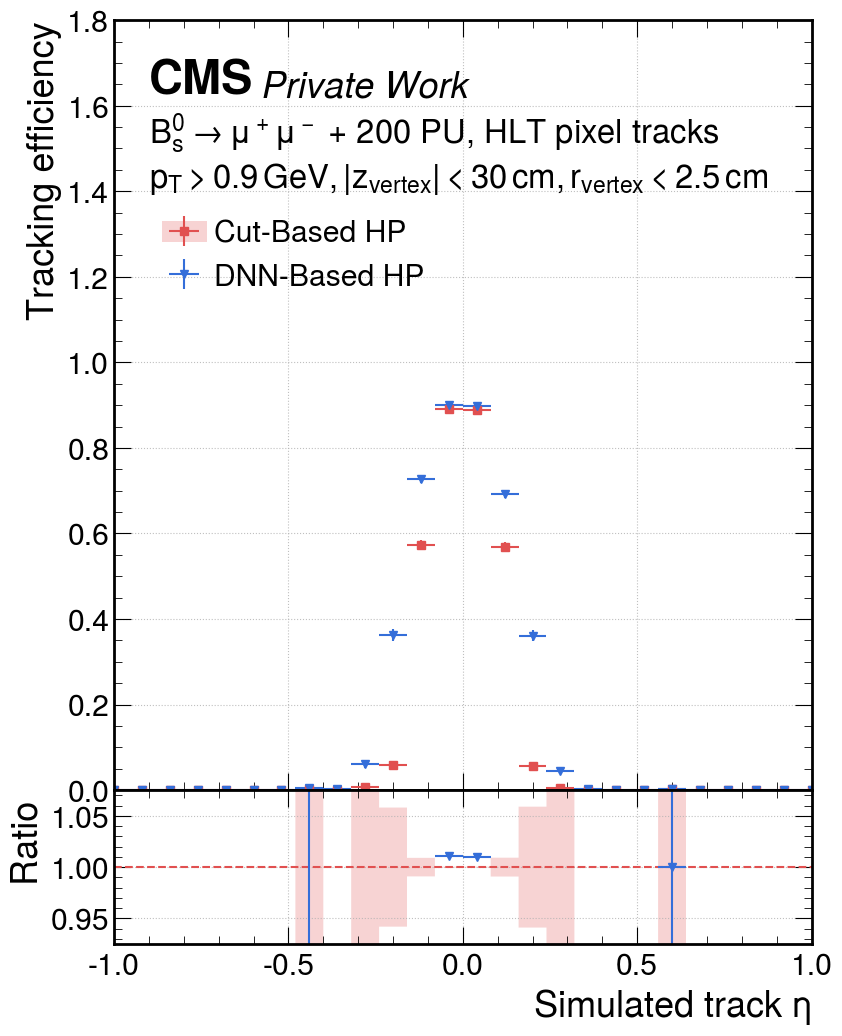

In [59]:
explumi = fillEfficiency( HIST = "efficiencyVsdxy",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking efficiency",
                XLABEL="Simulated track $\eta$",
                Ylim=(0.,1),
                ratioYlim=(0.925, 1.075),
                Xlim=(-1,1),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=True,
                FILLCURVES=False,
                FILLALPHA=0.90, 
                INSET=False,
                saveas=saveas
              )

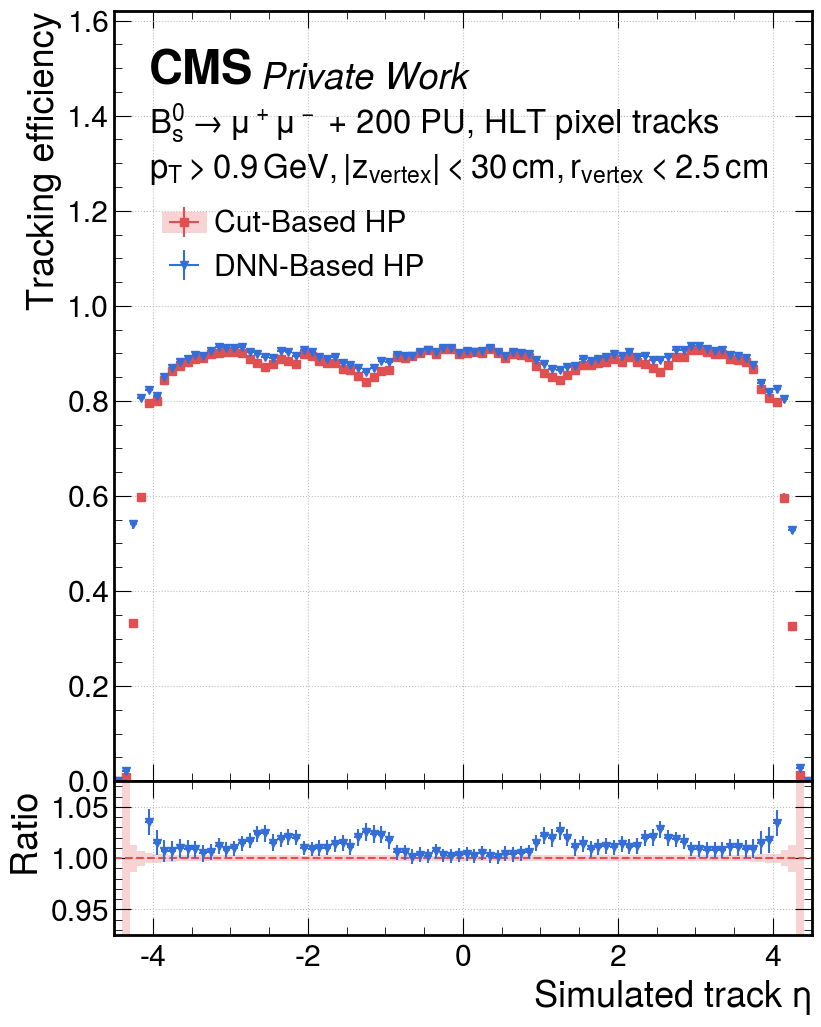

In [43]:
explumi = fillEfficiency( HIST = "efficiencyVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking efficiency",
                XLABEL="Simulated track $\eta$",
                Ylim=(0.,.9),
                ratioYlim=(0.925, 1.075),
                Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=True,
                FILLCURVES=False,
                FILLALPHA=0.90, 
                INSET=False,
                saveas=saveas
              )

/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:16: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(numHist.values == 0, 0, numHist.errors / numHist.values)
/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + (denomHist.errors/denomHist.values)**2))


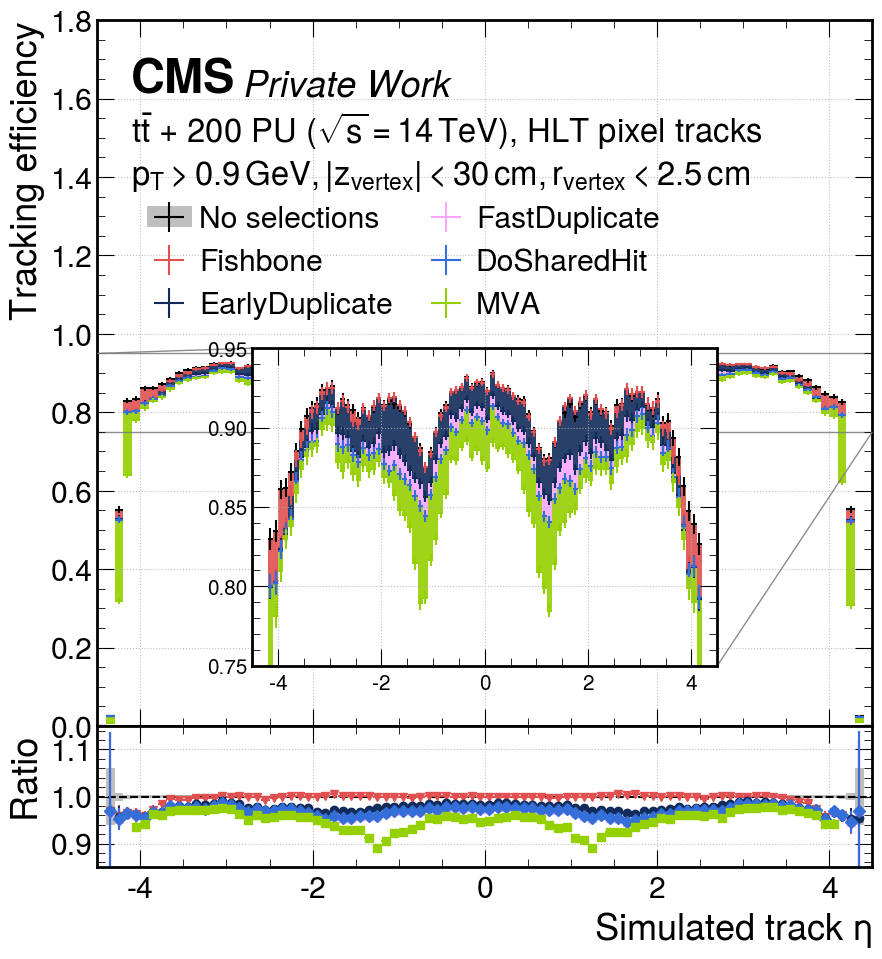

In [17]:
explumi = fillEfficiency( HIST = "efficiencyVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking efficiency",
                XLABEL="Simulated track $\eta$",
                Ylim=(0.,1.),
                ratioYlim=(0.85, 1.15),
                Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                FILLCURVES=True,
                FILLALPHA=0.90, 
                INSET=True,
                saveas=saveas
              )

/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:16: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(numHist.values == 0, 0, numHist.errors / numHist.values)
/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + (denomHist.errors/denomHist.values)**2))


AttributeError: 'NoneType' object has no attribute 'set_fontsize'

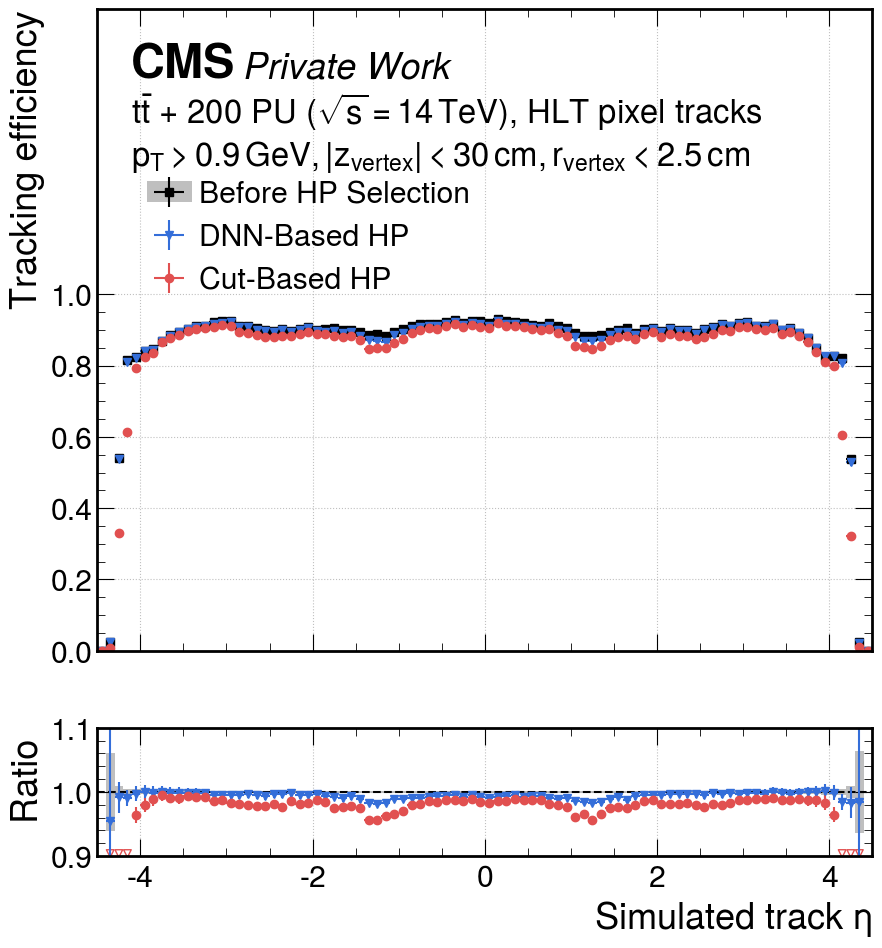

In [21]:
explumi = plotEfficiency( HIST = "efficiencyVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking efficiency",
                XLABEL="Simulated track $\eta$",
                Ylim=(0,1.),
                ratioYlim=(0.9, 1.1),
                Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=True,
                saveas=saveas
              )

TypeError: cannot unpack non-iterable NoneType object

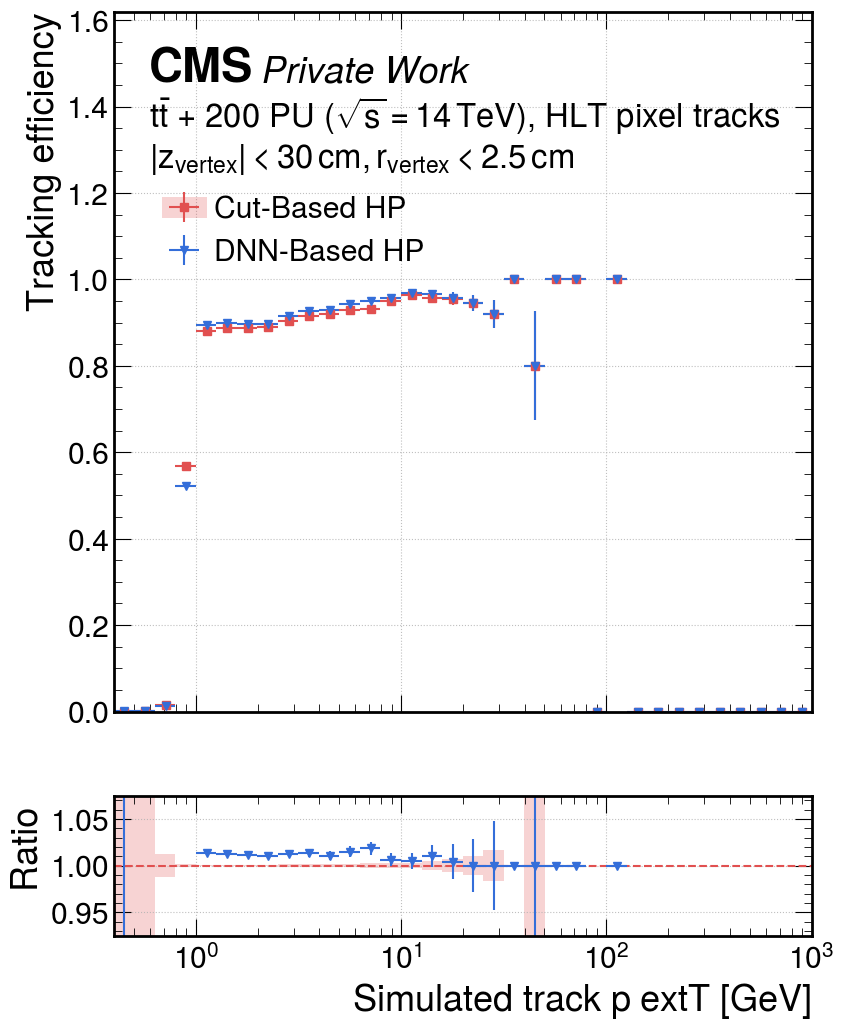

In [10]:
explumi = fillEfficiency( HIST = "efficiencyVsPt",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking efficiency",
                XLABEL="Simulated track $p_\text{T}$ [GeV]",
                Ylim=(0.,.9),
                ratioYlim=(0.925, 1.075),
                Xlim=(4e-1,1e3),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=True,
                FILLCURVES=False,
                FILLALPHA=0.90, 
                INSET=False,
                saveas=saveas
              )

/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:16: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(numHist.values == 0, 0, numHist.errors / numHist.values)
/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + (denomHist.errors/denomHist.values)**2))


AttributeError: 'NoneType' object has no attribute 'set_fontsize'

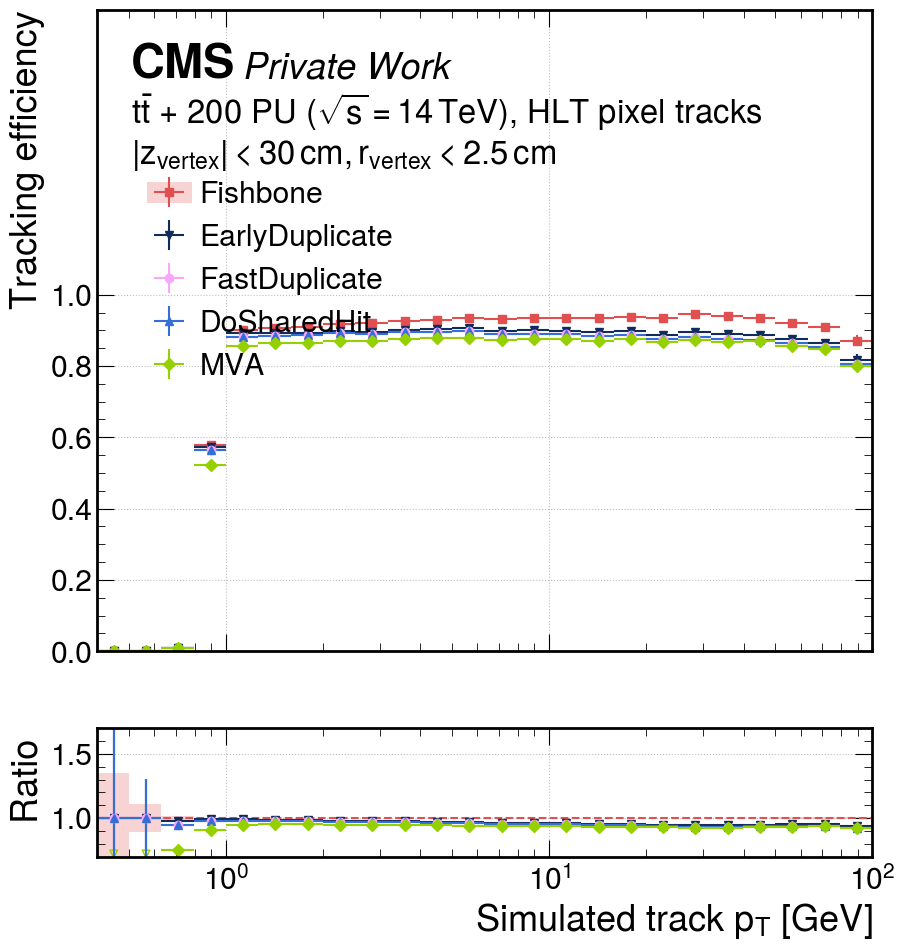

In [11]:
explumi = plotEfficiency( HIST = "efficiencyVsPt",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking efficiency",
                XLABEL=r"Simulated track $p_\text{T}$ [GeV]",
                Ylim=(0,1.),
                ratioYlim=(0.7, 1.7),
                Xlim=(4e-1,1e2),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                saveas=saveas
              )

In [ ]:
explumi = plotEfficiency( HIST = "efficiencyVsPhi",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking efficiency",
                XLABEL=r"Simulated track $\phi$ [rad]",
                Ylim=(0,1.),
                ratioYlim=(0.7, 1.7),
                Xlim=(-np.pi,np.pi),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                saveas=saveas
              )

/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:16: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(numHist.values == 0, 0, numHist.errors / numHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: divide by zero encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: divide by zero encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + 

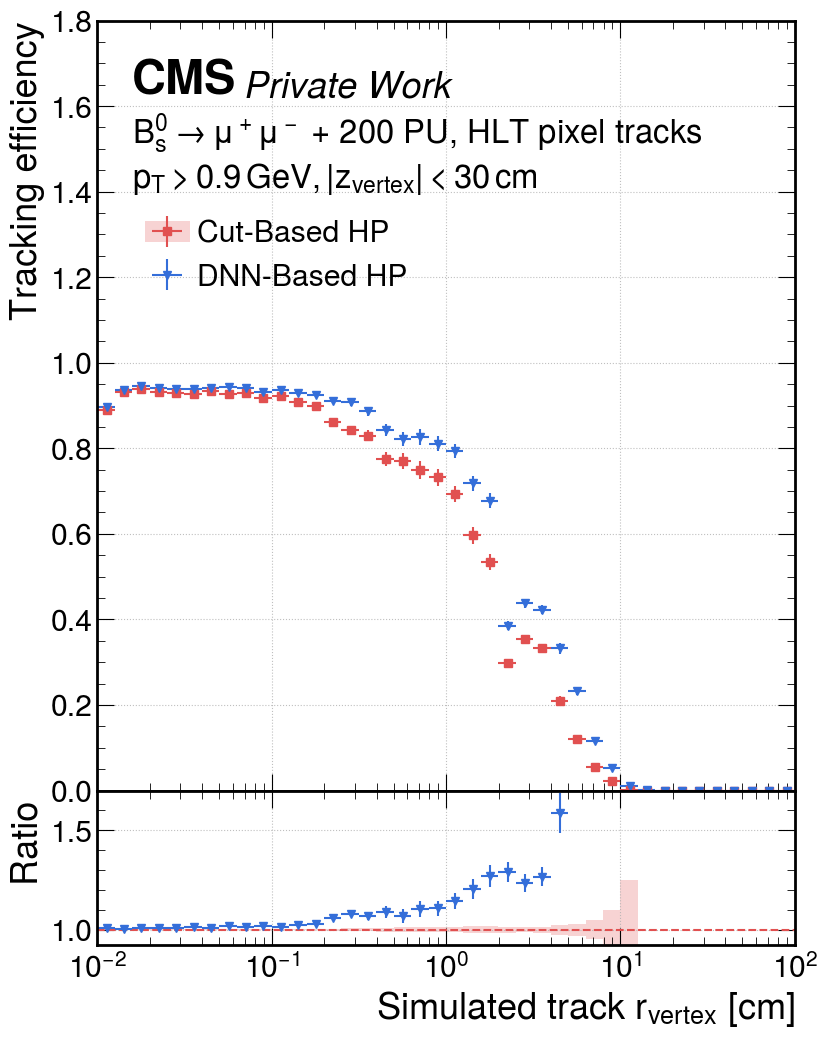

In [68]:
explumi = fillEfficiency( HIST = "efficiencyVsVertex",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                XLABEL=r"Simulated track $r_\text{vertex}$ [cm]",
                YLABEL="Tracking efficiency",
                ratioYlim=(0.925, 1.7),
                XSCALE="log",
                Ylim=(0,1.),
                Xlim=(1e-2,1e2),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=True,
                FILLCURVES=False,
                FILLALPHA=0.90, 
                INSET=False,
                saveas=saveas
              )

/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:16: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(numHist.values == 0, 0, numHist.errors / numHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: divide by zero encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: divide by zero encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + 

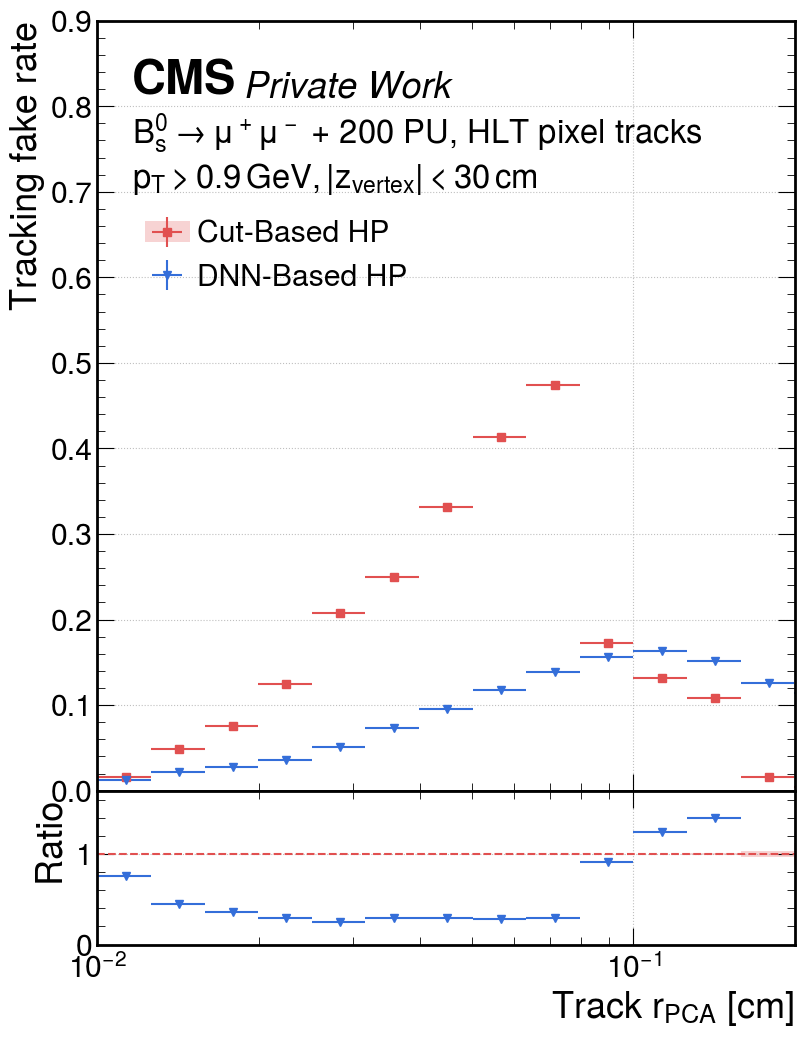

In [66]:
explumi = fillEfficiency( HIST = "fakeVsVertex",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                XLABEL=r"Track $r_\text{PCA}$ [cm]",
                YLABEL="Tracking fake rate",
                ratioYlim=(0, 1.7),
                XSCALE="log",
                Ylim=(0,.5),
                Xlim=(1e-2,2e-1),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=True,
                FILLCURVES=False,
                FILLALPHA=0.90, 
                INSET=False,
                saveas=saveas
              )

KeyError: 'fake+dupVsVertex'

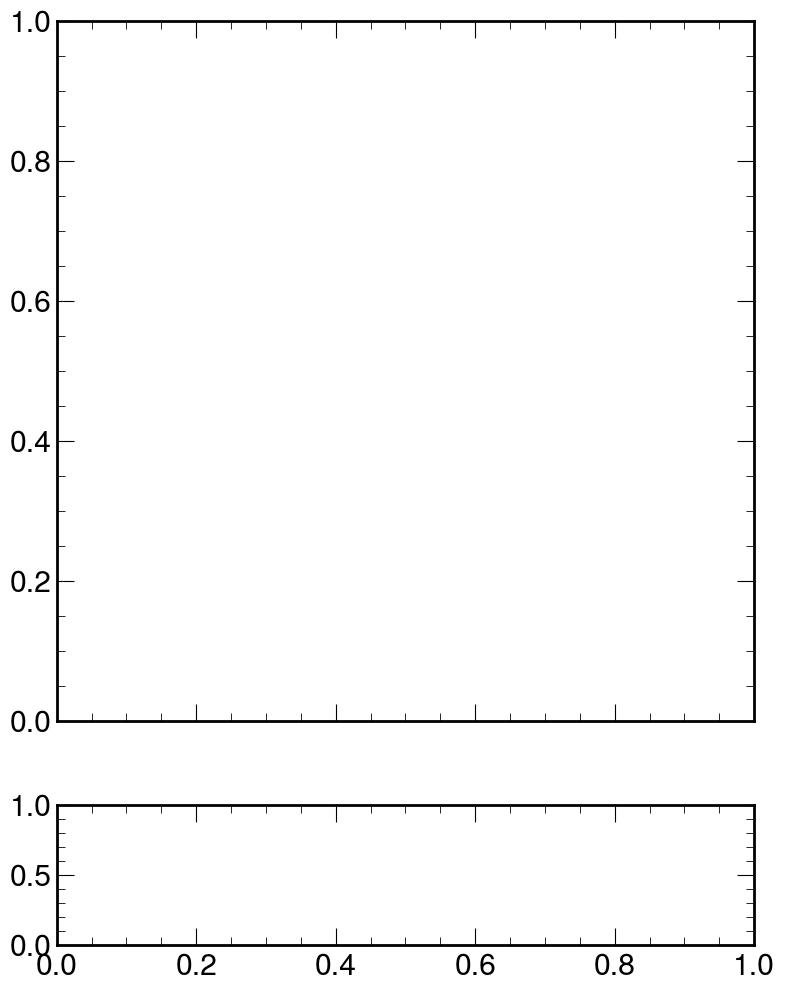

In [51]:
explumi = fillEfficiency( HIST = "fake+dupVsVertex",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                XLABEL=r"Track $r_\text{vertex}$ [cm]",
                YLABEL="Tracking fake rate",
                ratioYlim=(0.925, 1.6),
                XSCALE="log",
                Ylim=(0,1.),
                Xlim=(1e-2,1e2),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=True,
                FILLCURVES=False,
                FILLALPHA=0.90, 
                INSET=False,
                saveas=saveas
              )

/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + (denomHist.errors/denomHist.values)**2))


AttributeError: 'NoneType' object has no attribute 'set_fontsize'

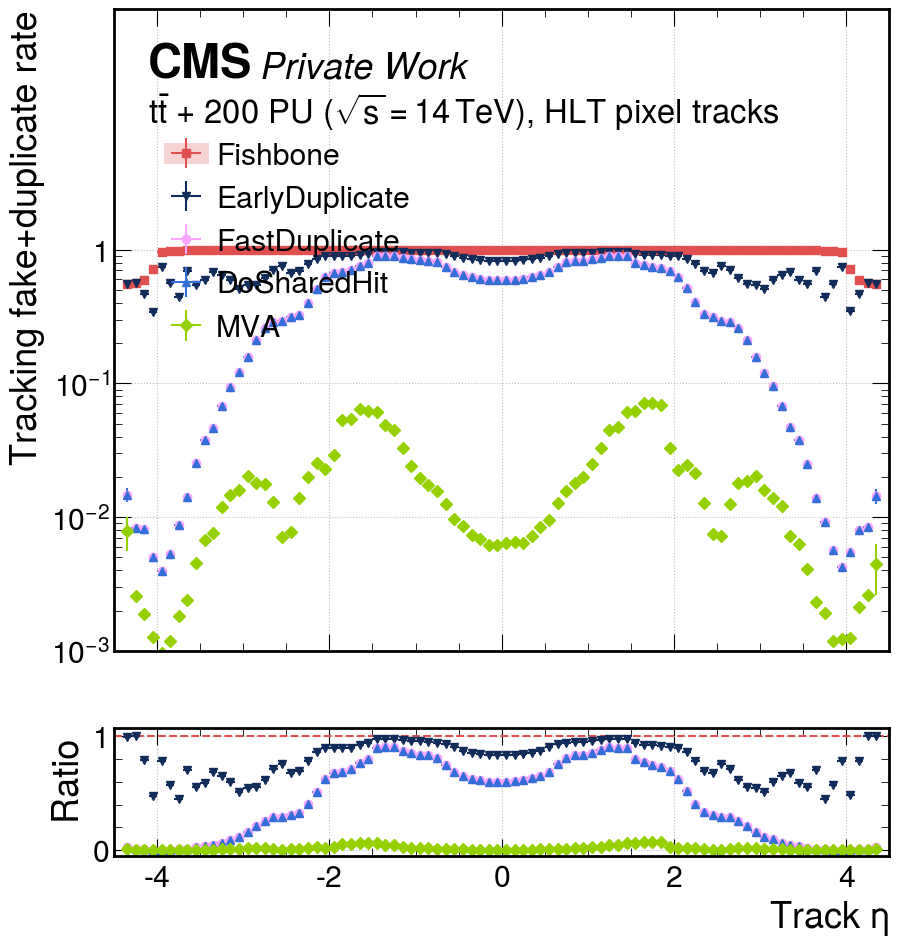

In [16]:
# Fake+dup vs eta
plotEfficiency( HIST = "fake+dupVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                #Ylim=(0,0.8),
                Ylim=(1e-3,1), #(5e-5,0.03),
                YSCALE="log",
                #ratioYlim=(0.0, 5),
                Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                YLABEL="Tracking fake+duplicate rate",
                XLABEL="Track $\eta$",
                saveas=saveas
              )

In [ ]:
# Fake+dup vs eta
plotEfficiency( HIST = "fake+dupVsPt",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                #Ylim=(0,0.8),
                Ylim=(1e-3,1), #(5e-5,0.03),
                YSCALE="log",
                #ratioYlim=(0.0, 5),
                Xlim=(4e-1,1e2),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                YLABEL="Tracking fake+duplicate rate",
                XLABEL=r"Track $p_\text{T}$ [GeV]",
                saveas=saveas
              )

KeyError: 'MVA_NP'

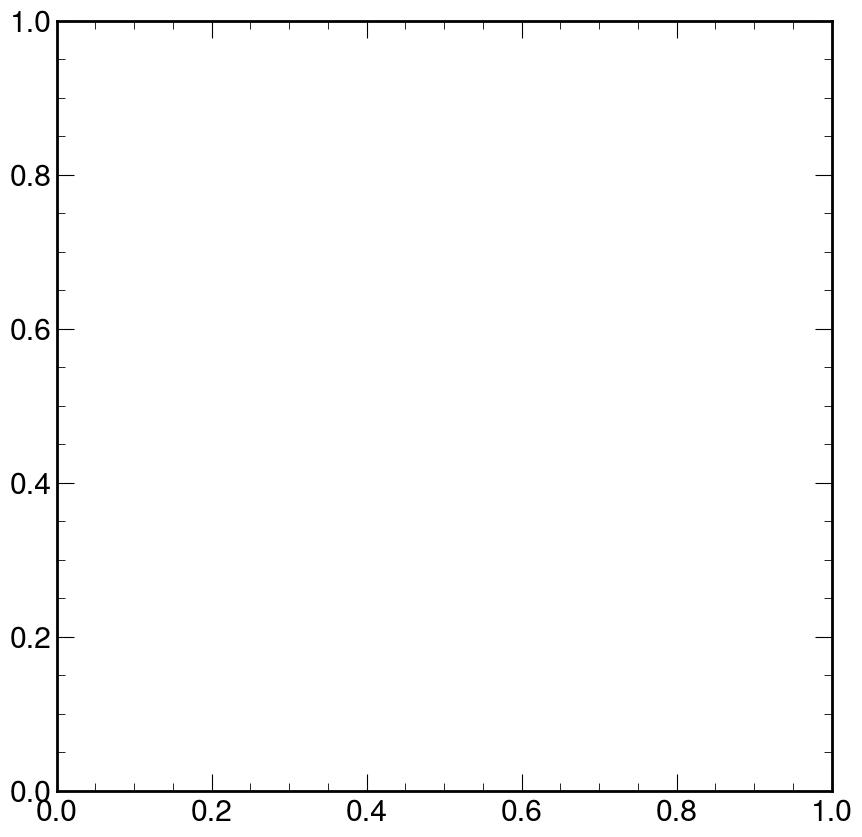

In [65]:
# Fake+dup vs eta
plotEfficiency( HIST = "fake+dupVsPhi",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                #Ylim=(0,0.8),
                Ylim=(1e-3,1e-2), #(5e-5,0.03),
                YSCALE="log",
                #ratioYlim=(0.0, 5),
                Xlim=(-np.pi,np.pi),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                YLABEL="Tracking fake+duplicate rate",
                XLABEL="Track $\phi$ [rad]",
                saveas=saveas
              )

/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:16: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(numHist.values == 0, 0, numHist.errors / numHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:19: RuntimeWarning: invalid value encountered in divide
  ratioHist.values = np.where(denomIsZero, np.nan, numHist.values / denomHist.values)
/eos/home-i03/e/ecoradin/GitHub/plot-thesis/TEDD-extension/sakura/sakura/tools/getRatioHist.py:20: RuntimeWarning: invalid value encountered in divide
  ratioHist.errors = np.where(denomIsZero, 0, np.abs(numHist.values / denomHist.values) * np.sqrt((numHist.errors/numHist.values)**2 + (denomHist.errors/denomHist.values)**2))


TypeError: cannot unpack non-iterable NoneType object

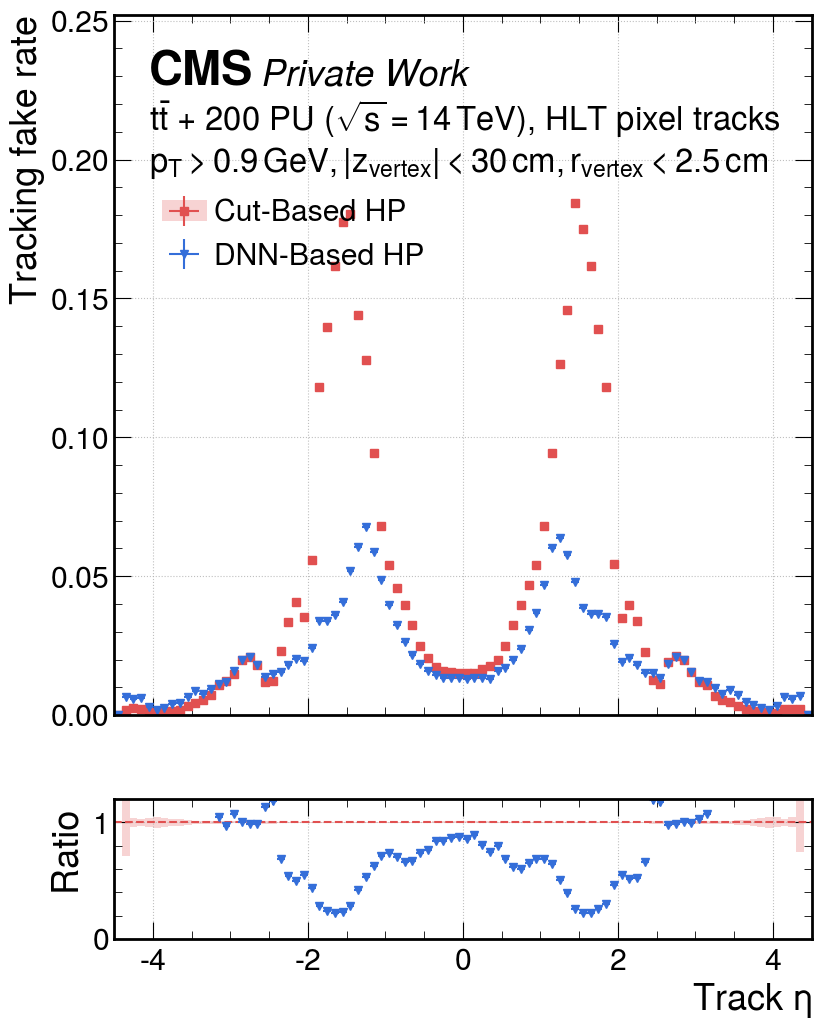

In [12]:
# Fake vs eta
fillEfficiency( HIST = "fakeVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                #Ylim=(1e-3,0.14),
                Ylim=(0,0.14),
                #YSCALE="log",
                ratioYlim=(0, 1.2),
                Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                #REMOVETICKS=True,
                RATIO=True,
                YLABEL="Tracking fake rate",
                XLABEL="Track $\eta$",
                #DRAFT=False,
                FILLCURVES=False,
                saveas=saveas
              )

TypeError: cannot unpack non-iterable NoneType object

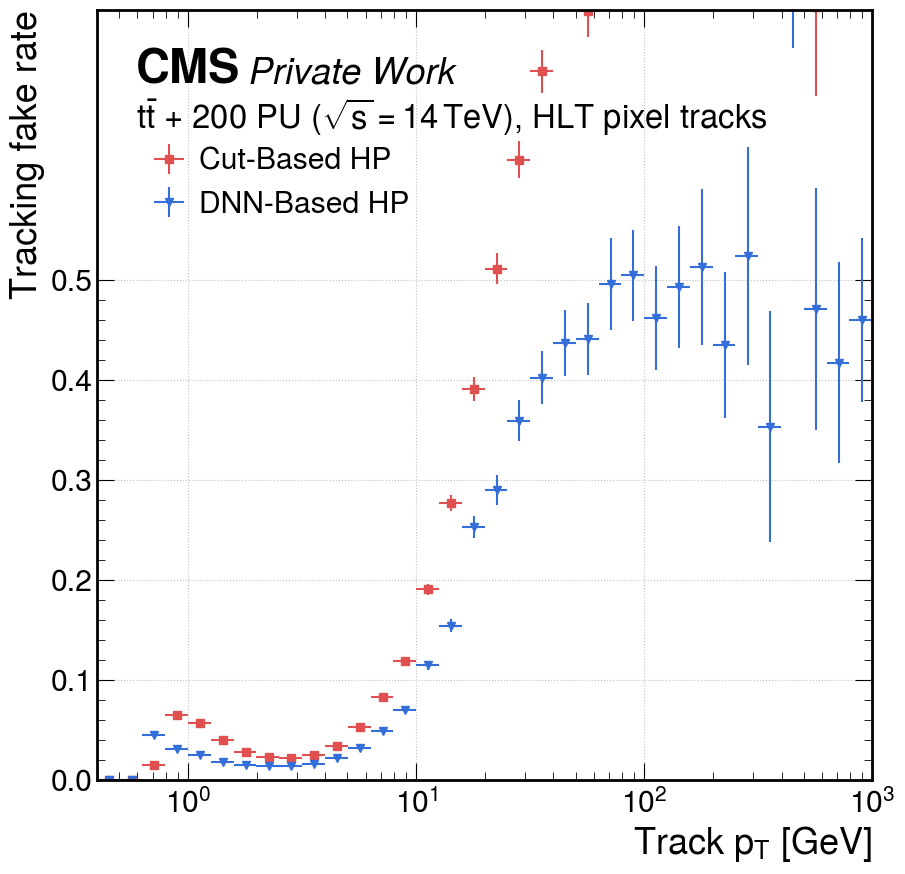

In [13]:
# Fake vs eta
plotEfficiency( HIST = "fakeVsPt",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                Ylim=(0,0.5),
                #YSCALE="log",
                #ratioYlim=(0.0, 5),
                Xlim=(4e-1,1e3),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                YLABEL="Tracking fake rate",
                XLABEL=r"Track $p_\text{T}$ [GeV]",
                #DRAFT=False,
                saveas=saveas
              )

In [ ]:
explumi = plotEfficiency( HIST = "fakeVsPhi",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking fake rate",
                XLABEL=r"Track $\phi$ [rad]",
                Ylim=(8e-3,1e-1),
                YSCALE="log",
                ratioYlim=(0.7, 1.7),
                Xlim=(-np.pi,np.pi),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                saveas=saveas
              )

In [ ]:
# Dups vs eta
plotEfficiency( HIST = "dupVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                Ylim=(0,0.015), #(5e-5,0.03),
                #YSCALE="log",
                ratioYlim=(-1, 4.9),
                Xlim=(-4.5,4.5),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                YLABEL="Tracking duplicate rate",
                XLABEL="Track $\eta$",
                saveas=saveas
              )

In [ ]:
# Fake vs eta
plotEfficiency( HIST = "dupVsPt",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                Ylim=(5e-5,1),
                YSCALE="log",
                #ratioYlim=(0.0, 5),
                Xlim=(4e-1,1e2),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                YLABEL="Tracking duplicate rate",
                XLABEL=r"Track $p_\text{T}$ [GeV]",
                #DRAFT=False,
                saveas=saveas
              )

In [ ]:
explumi = plotEfficiency( HIST = "dupVsPhi",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                YLABEL="Tracking duplicate rate",
                XLABEL=r"Track $\phi$ [rad]",
                Ylim=(0.,0.003),
                #YSCALE="log",
                ratioYlim=(0.7, 1.7),
                Xlim=(-np.pi,np.pi),
                LEGEND=LEGEND,
                REMOVETICKS=True,
                RATIO=RATIO,
                saveas=saveas
              )

In [ ]:
# pt res vs eta
plotEfficiency( HIST = "ptresVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                Ylim=(1e-2,1e-1),
                YSCALE="log",
                ratioYlim=(0.5, 1.1),
                Xlim=(-4.5,4.5),
                YLABEL=r"$p_\text{T}$ track resolution $\sigma\left( \delta p_\text{T} / p_\text{T} \right)$",
                XLABEL="Simulated track $\eta$",
                LEGEND=LEGEND,
                RATIO=RATIO,
                saveas=saveas
              )

In [ ]:
# phi res vs eta
plotEfficiency( HIST = "phiresVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                Ylim=(0.9e-3,1e-2),
                ratioYlim=(0.85, 1.15),
                Xlim=(-4.5,4.5),
                YSCALE="log",
                YLABEL=r"$\phi$ track resolution $\sigma\left( \delta \phi \right)$ [rad]",
                XLABEL="Simulated track $\eta$",
                LEGEND=LEGEND,
                RATIO=RATIO,
                saveas=saveas)

In [ ]:
# dxy res vs eta
plotEfficiency( HIST = "dxyresVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                #Ylim=(0,0.35e-1),
                Ylim=(3.8e-3,3e-2),
                ratioYlim=(0.9, 1.1),
                Xlim=(-4.5,4.5),
                YSCALE="log",
                YLABEL="Transverse impact parameter\n" + r"resolution $\sigma\left( \delta d_0 \right)$ [µm]",
                XLABEL="Simulated track $\eta$",
                LEGEND=LEGEND,
                RATIO=RATIO,
                FACTOR=1e4,
                saveas=saveas)

In [ ]:
# dz res vs eta
plotEfficiency( HIST = "dzresVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                Ylim=(4e-3,5e-1),
                ratioYlim=(0.9, 1.1),
                Xlim=(-4.5,4.5),
                YSCALE="log",
                YLABEL="Longitudinal impact parameter\nresolution " + r"$\sigma\left( \delta d_z \right)$ [µm]",
                XLABEL="Simulated track $\eta$",
                LEGEND=LEGEND,
                RATIO=RATIO,
                FACTOR=1e4,
                saveas=saveas)

In [ ]:
# hits vs eta
plotEfficiency( HIST = "hitsVsEta",
                CURVS = CURVS,
                MARKERS = MARKERS,
                COLORS = COLORS,
                Ylim=(0,11),
                ratioYlim=(-0.5, 2.8),
                Xlim=(-4.5,4.5),
                #YSCALE="log",
                ratioTYPE="diff",
                YLABEL=r"Average number of hits per track $\langle N_\text{hits} \rangle$",
                XLABEL="Track $\eta$",
                LEGEND=LEGEND,
                RATIO=RATIO,
                saveas=saveas)